# Preliminary work on a possible radio follow-up

(Work done by Baptiste Bernard during his M1 internship)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import afterglowpy as grb
import pickle
import sys

In [2]:
sys.path.append('/home/masson/afterglowpy/orphan_modules')
from tools import mag_to_flux, flux_to_mag

In [3]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## How much time between a first identification in optical and a last detection in radio?

In [4]:
file_open = open('/home/masson/afterglowpy/data/orphans_pseudo_obs_5pts_low_redshift.pkl', 'rb')
orphan_pop = pickle.load(file_open)
file_open.close()

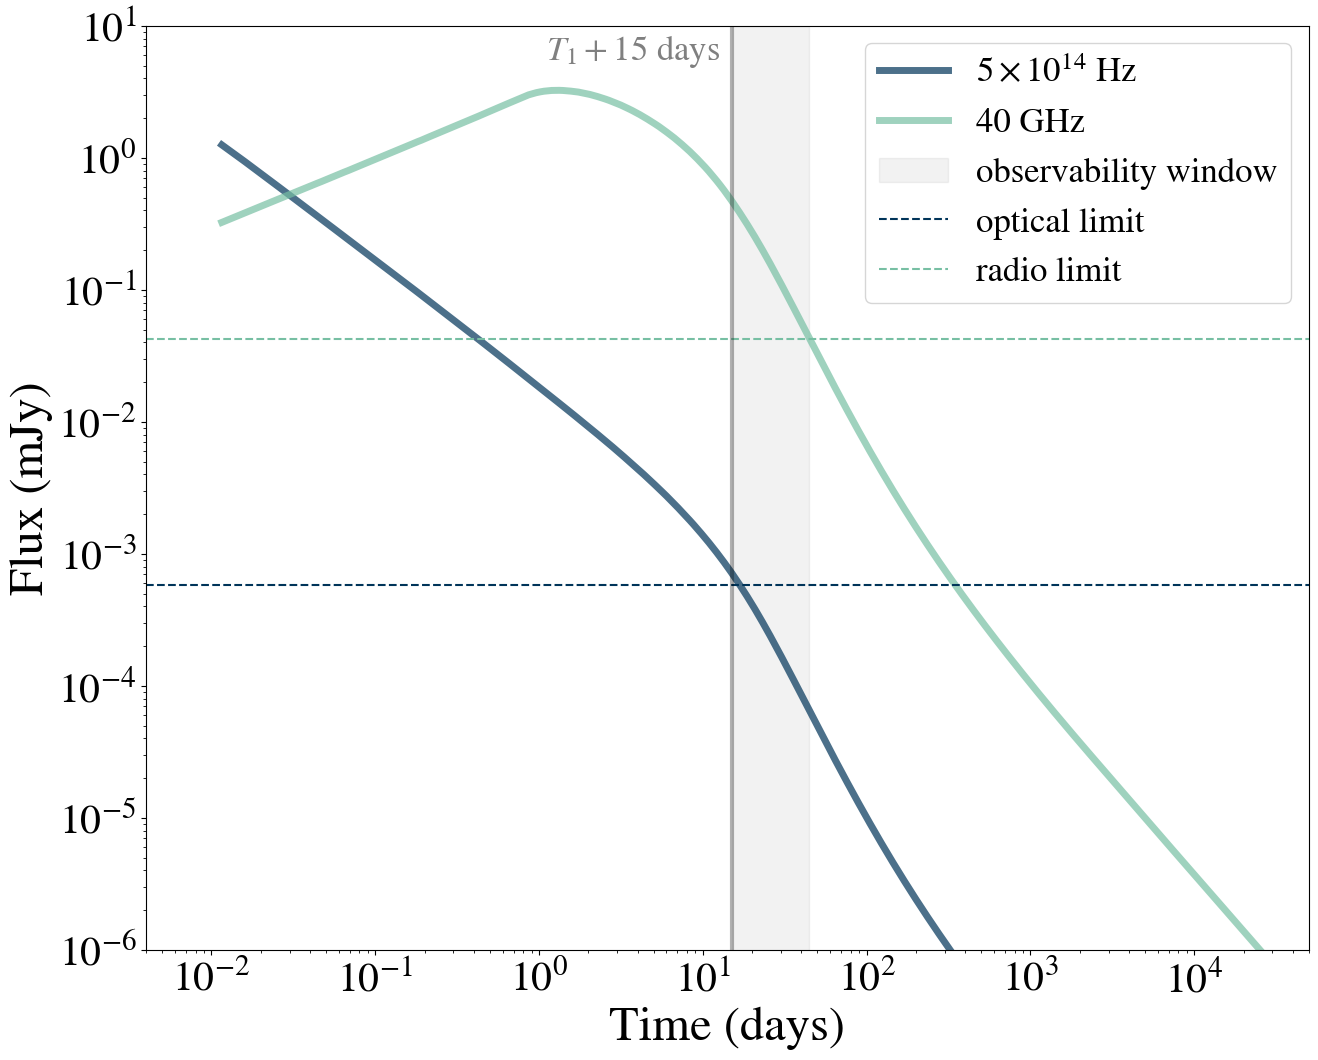

In [5]:
Z = {'jetType':     grb.jet.PowerLaw,     # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,       # Power Law index
     'thetaObs':    0.5,     # Viewing angle in radians
     'E0':          1.0e53,  # Isotropic-equivalent energy in erg
     'thetaWing':   0.25,    # Truncation angle in radians
     'thetaCore':   0.08,     # Half-opening angle in radians
     'n0':          1.0,     # Circumburst density in cm^{-3}
     'p':           2.2,     # Electron energy distribution index
     'epsilon_e':   0.1,     # epsilon_e
     'epsilon_B':   0.01,    # epsilon_B
     'xi_N':        1.0,     # Fraction of electrons accelerated
     'd_L':         1.2488755033518146e27,  # Luminosity distance in cm
     'z':           0.08601737447284925}    # Redshift

t = np.geomspace(1.0e3, 1.0e10, 300)

nu_opt = 5.0e14   # r-band
nu_radio = 10.0e9

colors_opt = '#003459'
colors_radio = '#77bfa3'

label = [r'$5 \times 10^{14}$ Hz', '40 GHz']

plt.rcParams.update({'font.size': 30})
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# Calculate the flux in Jansky and the AB Magnitude for each jet type and plot the magnitude
for nu, c, l in zip([nu_opt, nu_radio], [colors_opt, colors_radio], label):
    if nu==nu_opt:
        Fnu_opt = grb.fluxDensity(t, nu, **orphan_pop[0]['config'])  
        plt.plot(t*grb.sec2day, Fnu_opt, color=c, alpha=0.7, lw=5, label=l)
    else:
        Fnu_rad = grb.fluxDensity(t, nu, **orphan_pop[0]['config'])  
        plt.plot(t*grb.sec2day, Fnu_rad, color=c, alpha=0.7, lw=5, label=l)
        
t_start = (t[np.where(Fnu_opt[Fnu_opt>mag_to_flux(24.5)])[0]])[0] * grb.sec2day + 15.
t_end = t[np.where(Fnu_rad[Fnu_rad>0.0425])][-1] * grb.sec2day

plt.fill_between([t_start, t_end], 1e-7, 10, color='k', alpha=0.05, label='observability window')
plt.xlabel('Time (days)', fontsize=35)
plt.ylabel('Flux (mJy)', fontsize=35)
plt.axhline(y=mag_to_flux(24.5), c='#003459', ls='--', label='optical limit')
plt.axhline(y=0.0425, c='#77bfa3', ls='--', label='radio limit')
plt.axvline(x=t_start, c='k', lw=3, alpha=0.3)
plt.text(1.1, 5.5, '$T_1 + 15$ days', fontsize=25, c='grey')
plt.xscale('log')
plt.yscale('log')
plt.xlim(4e-3, 5e4)
plt.ylim(1e-6, 1e1)

plt.legend(fontsize=25)

#plt.savefig('../figures/orphan_obs_window.pdf', format="pdf", bbox_inches="tight", transparent=True)

## Light curves in optical and in radio

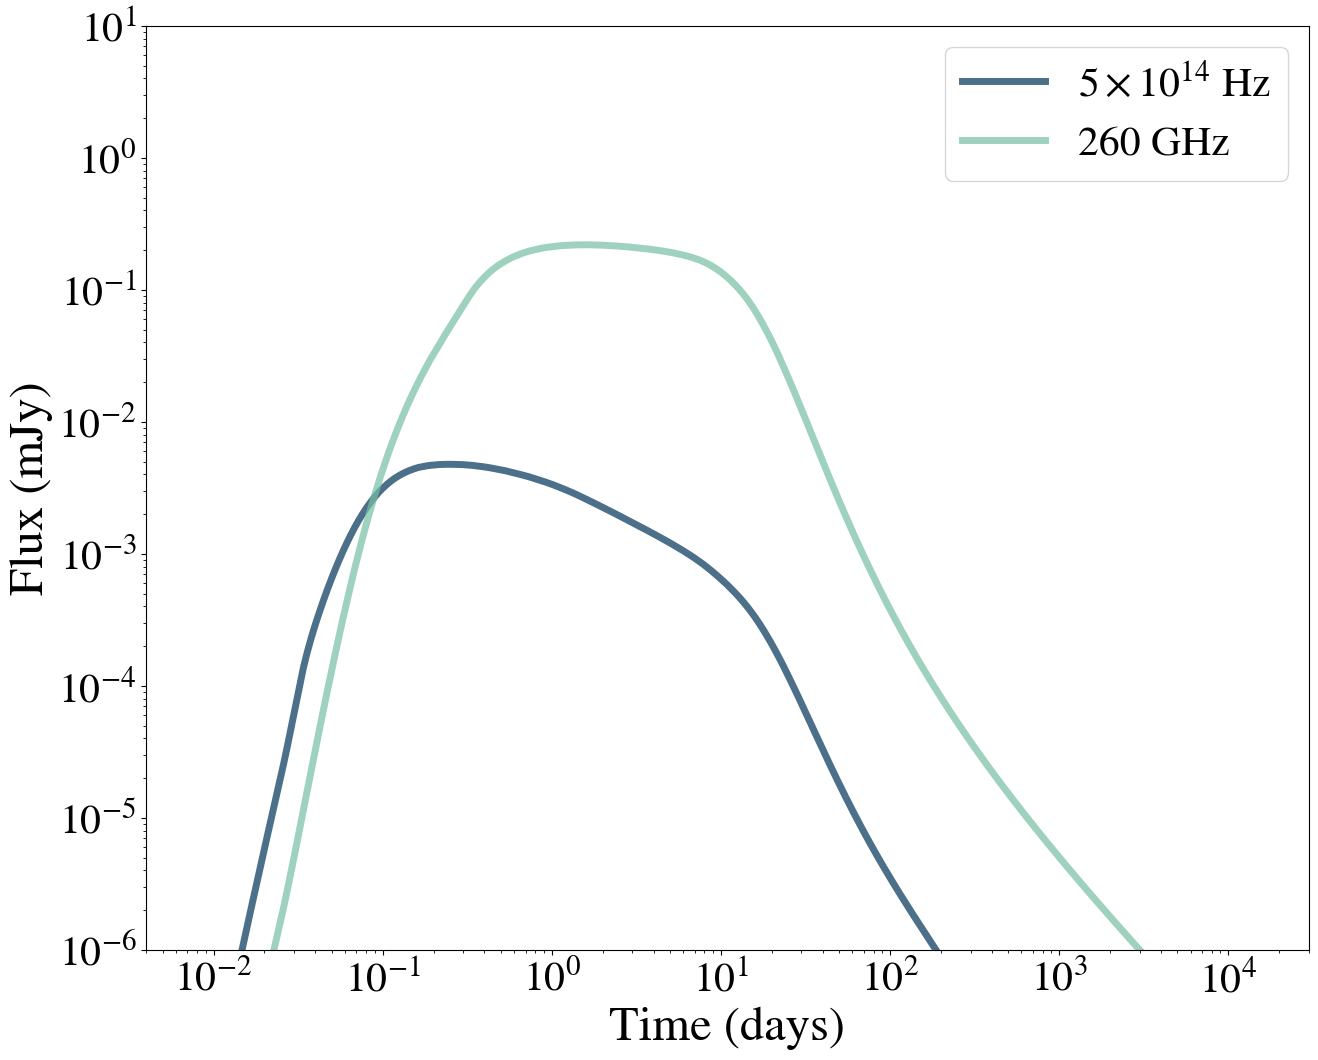

In [6]:
Z = {'jetType':     grb.jet.PowerLaw,     # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,       # Power Law index
     'thetaObs':    0.25,     # Viewing angle in radians
     'E0':          1.0e53,  # Isotropic-equivalent energy in erg
     'thetaWing':   0.2,    # Truncation angle in radians
     'thetaCore':   0.05,     # Half-opening angle in radians
     'n0':          1.0,     # Circumburst density in cm^{-3}
     'p':           2.2,     # Electron energy distribution index
     'epsilon_e':   0.1,     # epsilon_e
     'epsilon_B':   0.01,    # epsilon_B
     'xi_N':        1.0,     # Fraction of electrons accelerated
     'd_L':         1.0e28,  # Luminosity distance in cm
     'z':           0.55}    # Redshift

t = np.geomspace(1.0e3, 1.0e10, 300)

nu_opt = 5.0e14   # r-band
nu_radio = 260.0e9

colors_opt = '#003459'
colors_radio = '#77bfa3'

label = [r'$5 \times 10^{14}$ Hz', '260 GHz']

plt.rcParams.update({'font.size': 30})
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# Calculate the flux in Jansky and the AB Magnitude for each jet type and plot the magnitude
for nu, c, l in zip([nu_opt, nu_radio], [colors_opt, colors_radio], label):
    if nu==nu_opt:
        Fnu = grb.fluxDensity(t, nu, **Z)  
        plt.plot(t*grb.sec2day, Fnu, color=c, alpha=0.7, lw=5, label=l)
    else:
        Fnu = grb.fluxDensity(t, nu, **Z)  
        plt.plot(t*grb.sec2day, Fnu, color=c, alpha=0.7, lw=5, label=l)

plt.xlabel('Time (days)', fontsize=35)
plt.ylabel('Flux (mJy)', fontsize=35)
plt.xscale('log')
plt.yscale('log')
plt.xlim(4e-3, 3e4)
plt.ylim(1e-6, 1e1)

plt.legend()

#plt.savefig('../figures/orphan_opt_radio.pdf', format="pdf", bbox_inches="tight", transparent=True)

## Open the orphan population and compute their light curves at different frequency in radio

In [7]:
file_open = open('/home/masson/afterglowpy/data/orphans_pseudo_obs_5pts_low_redshift.pkl', 'rb')
orphan_pop = pickle.load(file_open)
file_open.close()

The cell below takes some time to run.

In [8]:
t = np.geomspace(0.1*grb.day2sec, 1400*grb.day2sec, 100) # le calcul va jusqu à 1400 jours car la fenetre d'opportunité la plus grande en optique est ~1370 jours

nu_opt = 5.0e14
nu_150 = 150.0e9
nu_260 = 260.0e9
nu_40 = 40.0e9
nu_10 = 10.0e9

Fnu_mab_pop = []
Fnu_150_pop = []
Fnu_260_pop = []
Fnu_40_pop = []
Fnu_10_pop = []

for oa in orphan_pop:
    
    z = oa['config']
    
    Fnu_mab_pop.append(-2.5 * np.log10(grb.fluxDensity(t, nu_opt, **z)*1.0e-26) - 48.6)
    Fnu_150_pop.append(grb.fluxDensity(t, nu_150, **z))
    Fnu_260_pop.append(grb.fluxDensity(t, nu_260, **z))
    Fnu_40_pop.append(grb.fluxDensity(t, nu_40, **z))
    Fnu_10_pop.append(grb.fluxDensity(t, nu_10, **z))

## Study their observability for different observatories

### NIKA2

#### Observability duration

In [9]:
seuil_LSST = 24.5  # Rubin nightly limiting magnitude 
seuil_NIKA2 = [2, 7.5]  # NIKA2 detection thresholds at 150 and 260 GHz respectively, for an observation time of ~1h at 5σ

# compute observability durations in optical and for NIKA2 frequency bands for the orphan population
fenetre_optik = []
fenetre_NIKA2_150 = []
fenetre_NIKA2_260 = []

for i in range(len(Fnu_mab_pop)):
    seuil_150 = np.where(Fnu_150_pop[i]>seuil_NIKA2[0])[0]
    seuil_260 = np.where(Fnu_260_pop[i]>seuil_NIKA2[1])[0]
    seuil_optik = np.where(Fnu_mab_pop[i]<seuil_LSST)[0]
    fenetre_optik.append((t[seuil_optik[-1]]-t[seuil_optik[0]])*grb.sec2day)
    if seuil_150.size!=0:
        fenetre_NIKA2_150.append((t[seuil_150[-1]]-t[seuil_optik[0]])*grb.sec2day)
    else:
        fenetre_NIKA2_150.append(0)
    if seuil_260.size!=0:
        fenetre_NIKA2_260.append((t[seuil_260[-1]]-t[seuil_optik[0]])*grb.sec2day)
    else:
        fenetre_NIKA2_260.append(0)

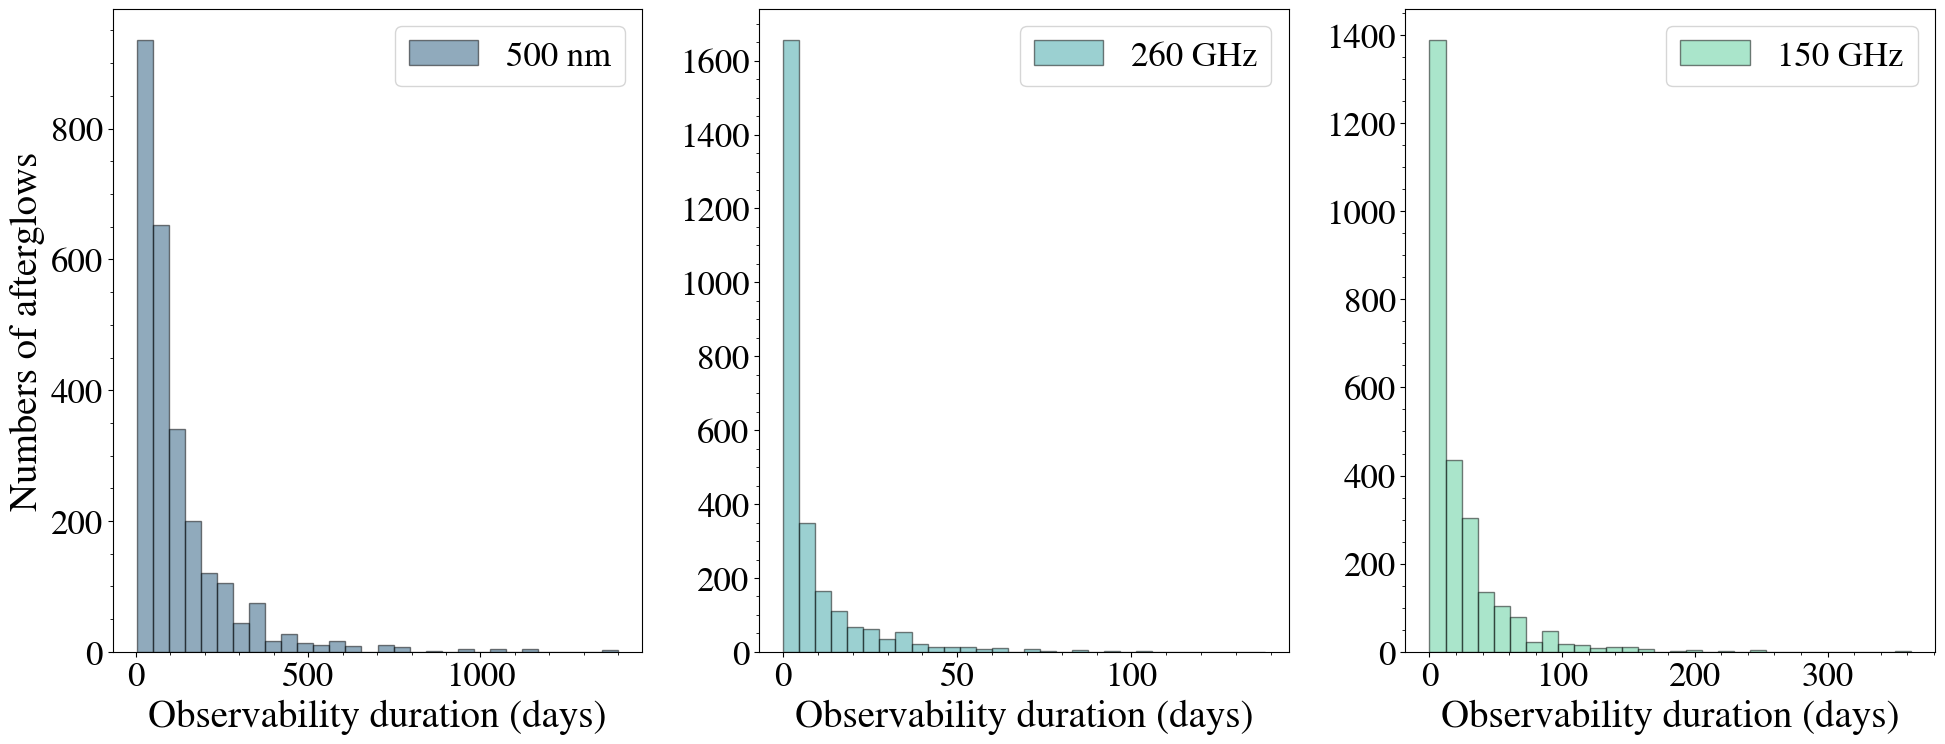

In [10]:
fenetre_NIKA2 = [fenetre_optik, fenetre_NIKA2_260, fenetre_NIKA2_150]
labels = ['500 nm', '260 GHz', '150 GHz']
colors = ['#22577a', '#38a3a5', '#57cc99']

plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(20,8))

for i in range(len(fenetre_NIKA2)):
    ax = plt.subplot(1,3,i+1)
    ax.hist(fenetre_NIKA2[i], color=colors[i], edgecolor='k', alpha=0.5, bins=30, label=labels[i])
    #plt.axvline(np.mean(params[i]),color='red',label=f'moyenne = {round(np.mean(params[i]))} jours')
    #plt.axvline(np.median(params[i]),color='orange',label=f'médiane = {round(np.median(params[i]))} jours')
    ax.set_xlabel('Observability duration (days)',fontsize=28)
    if i==0:
        ax.set_ylabel("Numbers of afterglows",fontsize=28)
    #ax.set_title(titles[i],fontsize=25)
    #plt.tick_params(which='both', length=10, labelsize=20)
    plt.minorticks_on()
    plt.legend(fontsize=25)

plt.tight_layout()
#plt.savefig('../figures/orphan_opt_radio_obs_duration.pdf', format="pdf", bbox_inches="tight", transparent=True)

#### Number of days after the peak in optical

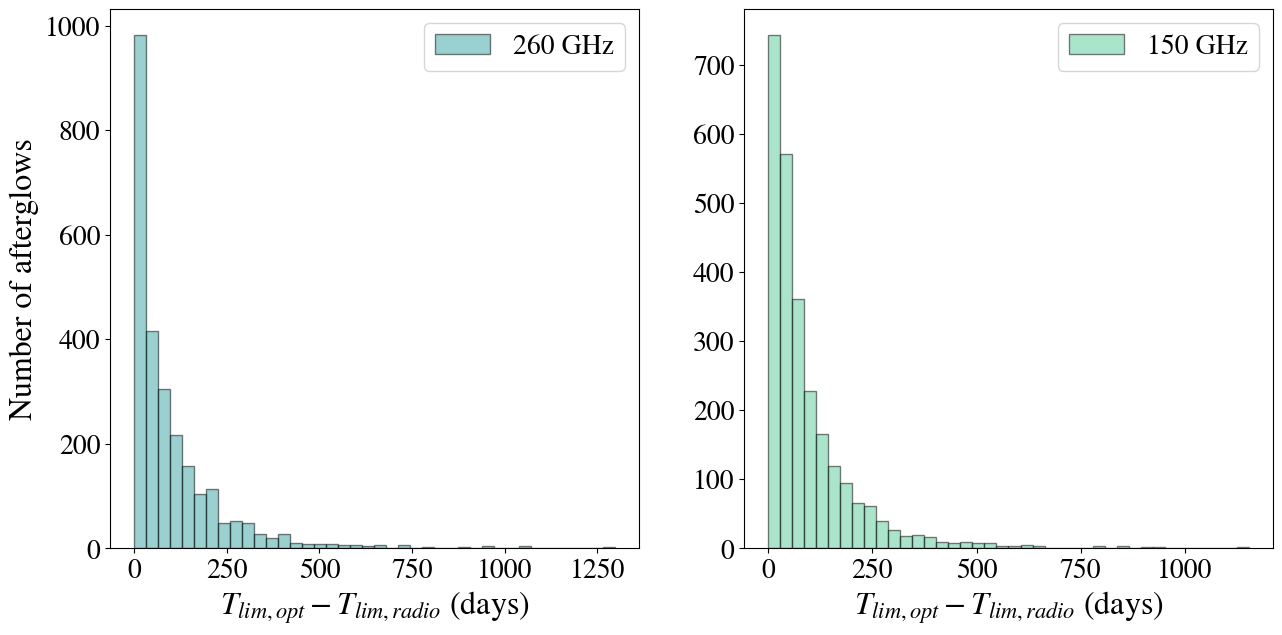

In [11]:
# compute the number of days between the last observation in optical and the last observation in radio
temps_150 = []
temps_260 = []

for i in range(len(Fnu_mab_pop)):
    seuil_150 = np.where(Fnu_150_pop[i]>2)[0]
    seuil_260 = np.where(Fnu_260_pop[i]>7.5)[0]
    seuil_optik = np.where(Fnu_mab_pop[i]<24.5)[0][-1]
    if seuil_150.size!=0:
        temps_150.append(t[seuil_optik]*grb.sec2day - t[seuil_150[-1]]*grb.sec2day)
    else:
        temps_150.append(0)
    if seuil_260.size!=0:
        temps_260.append(t[seuil_optik]*grb.sec2day - t[seuil_260[-1]]*grb.sec2day )
    else:
        temps_260.append(0)

params = [temps_260, temps_150]
labels = ['260 GHz', '150 GHz']
colors = ['#38a3a5', '#57cc99']

plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(15,7))
#plt.suptitle("Différence de temps entre le seuil en radio et en optique",fontsize=15)

for i in range(len(params)):
    ax = plt.subplot(1,2,i+1)
    ax.hist(params[i], bins=40, color=colors[i], edgecolor='k', alpha=0.5, label=labels[i])
    #plt.axvline(np.mean(params[i]),color='red',label=f'moyenne = {round(np.mean(params[i]))} jours')
    #plt.axvline(np.median(params[i]),color='orange',label=f'médiane = {round(np.median(params[i]))} jours')
    ax.set_xlabel('$T_{lim,opt} - T_{lim,radio}$ (days)', fontsize=23)
    if i==0:
        ax.set_ylabel("Number of afterglows", fontsize=23)
    plt.legend()
    
#plt.savefig('../figures/orphan_opt_radio_dt_threshold.pdf', format="pdf", bbox_inches="tight", transparent=True)

## VLA

#### Observability duration

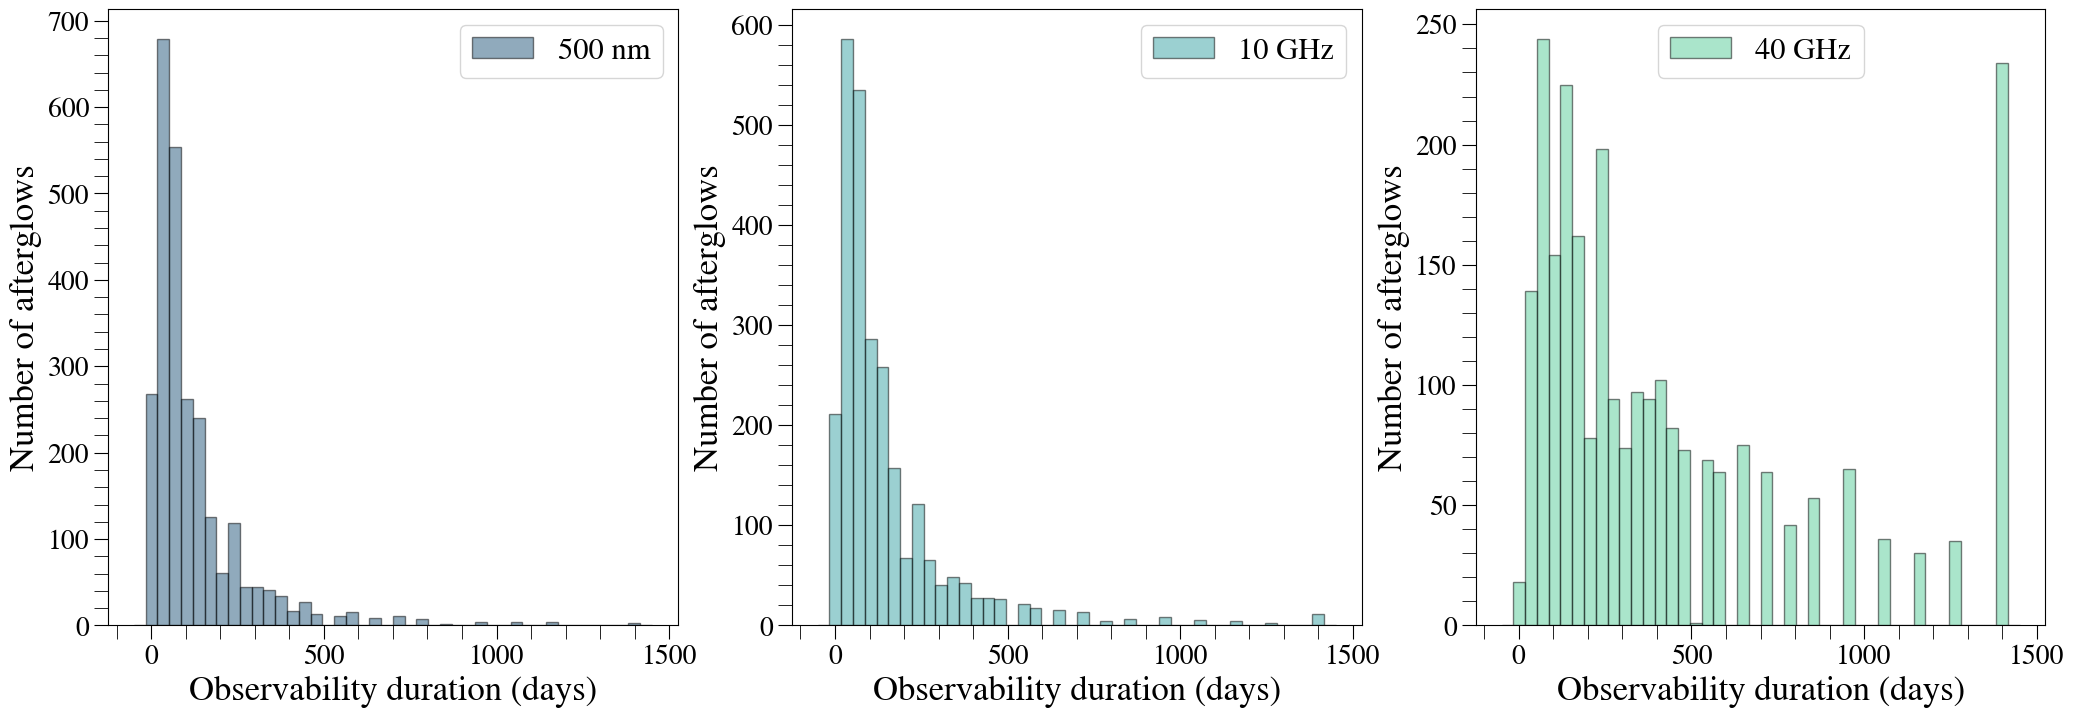

In [12]:
seuil_LSST = 24.5
seuil_VLA = [0.0425,0.174] # VLA detection thresholds at 10 and 40 GHz respectively, for an observation time of ~30 min at 5σ

fenetre_optik = []
fenetre_VLA_10 = []
fenetre_VLA_40 = []

for i in range(len(Fnu_mab_pop)):
    seuil_10 = np.where(Fnu_10_pop[i]>seuil_VLA[0])[0]
    seuil_40 = np.where(Fnu_40_pop[i]>seuil_VLA[1])[0]
    seuil_optik = np.where(Fnu_mab_pop[i]<seuil_LSST)[0]
    fenetre_optik.append((t[seuil_optik[-1]]-t[seuil_optik[0]])*grb.sec2day)
    if seuil_10.size!=0:
        fenetre_VLA_10.append((t[seuil_10[-1]]-t[seuil_optik[0]])*grb.sec2day)
    else:
        fenetre_VLA_10.append(0)
    if seuil_40.size!=0:
        fenetre_VLA_40.append((t[seuil_40[-1]]-t[seuil_optik[0]])*grb.sec2day)
    else:
        fenetre_VLA_40.append(0)

fenetre_VLA = [fenetre_optik, fenetre_VLA_40, fenetre_VLA_10]
titles = ['500 nm','10 GHz','40 GHz']
colors = ['#22577a', '#38a3a5', '#57cc99']

plt.figure(figsize=(25,8))

bin_edges = np.linspace(-50, 1450, 45)

for i in range(len(fenetre_VLA)):
    ax = plt.subplot(1,3,i+1)
    ax.hist(fenetre_VLA[i], bins=bin_edges, label=titles[i], color=colors[i], edgecolor='k', alpha=0.5)
    #plt.hist(params[i],log=True,bins=20,histtype='step',label=titles[i])
    #plt.axvline(np.mean(params[i]),color='red',label=f'moyenne = {round(np.mean(params[i]))} jours')
    #plt.axvline(np.median(params[i]),color='orange',label=f'médiane = {round(np.median(params[i]))} jours')
    ax.set_xlabel("Observability duration (days)",fontsize=25)
    ax.set_ylabel("Number of afterglows",fontsize=25)
    #ax.set_title(titles[i],fontsize=25)
    plt.tick_params(which='both',length=10,labelsize=20)
    plt.minorticks_on()
    plt.legend(fontsize=22)

## ALMA (+ comparison with NIKA2 and the VLA)

#### Observability duration

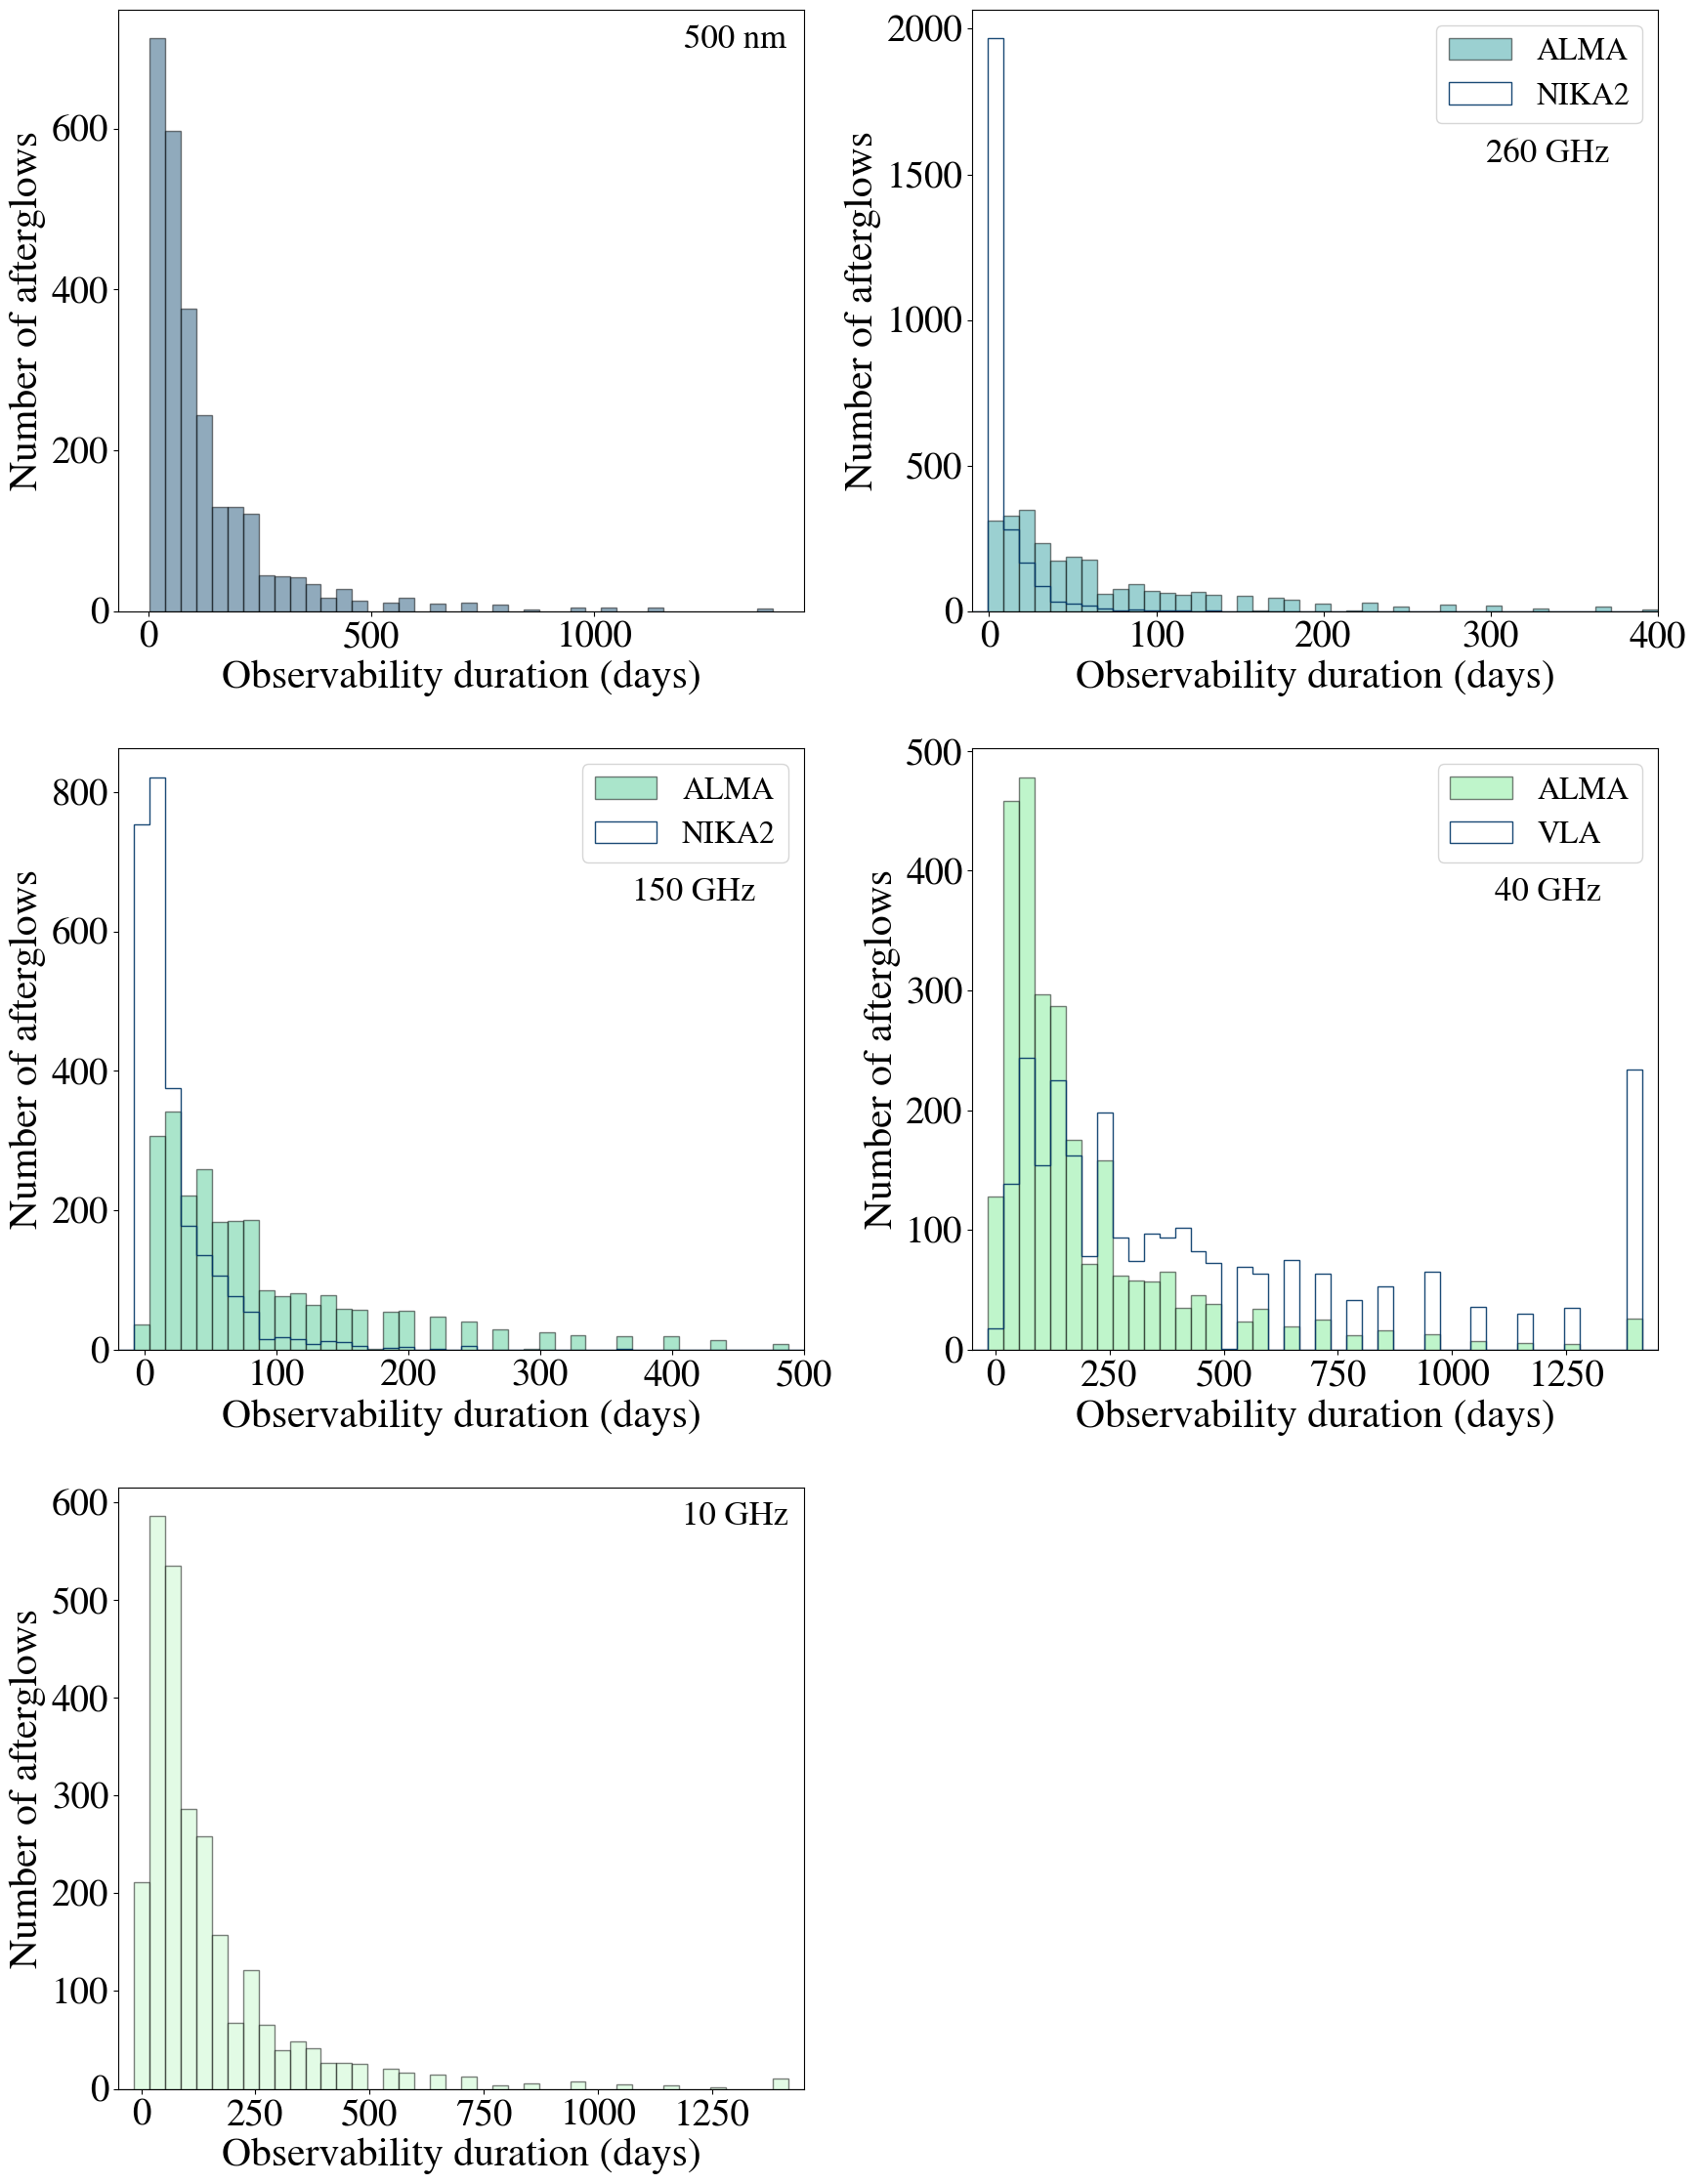

In [13]:
seuil_LSST = 24.5
seuil_ALMA = [0.105,0.165,0.215] # ALMA detection thresholds at 40, 150, 260 GHz respectively, for an observation time of ~10 min at 5σ

fenetre_optik = []
fenetre_ALMA_40 = []
fenetre_ALMA_150 = []
fenetre_ALMA_260 = []

for i in range(len(Fnu_mab_pop)):
    seuil_40 = np.where(Fnu_40_pop[i]>seuil_ALMA[0])[0]
    seuil_150 = np.where(Fnu_150_pop[i]>seuil_ALMA[1])[0]
    seuil_260 = np.where(Fnu_260_pop[i]>seuil_ALMA[2])[0]
    seuil_optik = np.where(Fnu_mab_pop[i]<seuil_LSST)[0]
    fenetre_optik.append((t[seuil_optik[-1]]-t[seuil_optik[0]])*grb.sec2day)
    if seuil_40.size!=0:
        fenetre_ALMA_40.append((t[seuil_40[-1]]-t[seuil_optik[0]])*grb.sec2day)
    else:
        fenetre_ALMA_40.append(0)
    if seuil_150.size!=0:
        fenetre_ALMA_150.append((t[seuil_150[-1]]-t[seuil_optik[0]])*grb.sec2day)
    else:
        fenetre_ALMA_150.append(0)
    if seuil_260.size!=0:
        fenetre_ALMA_260.append((t[seuil_260[-1]]-t[seuil_optik[0]])*grb.sec2day)
    else:
        fenetre_ALMA_260.append(0)

fenetre_ALMA = [fenetre_optik, fenetre_ALMA_260, fenetre_ALMA_150, fenetre_ALMA_40]
titles = ['500 nm','260 GHz (ALMA)','150 GHz (ALMA)','40 GHz']
colors = ['#22577a', '#38a3a5', '#57cc99','#80ed99', '#c7f9cc']

plt.rcParams.update({'font.size': 28})
plt.figure(figsize=(18,23))

for i in range(5):
    ax = plt.subplot(3,2,i+1)
    if i==1:
        bin_edges = np.linspace(-10, 400, 45)
        ax.hist(fenetre_ALMA[i], bins=bin_edges, label='ALMA', color=colors[i], edgecolor='k', alpha=0.5)
        ax.hist(fenetre_NIKA2[i], histtype='step', bins=bin_edges, color='#003566', lw=3, alpha=0.9, label='NIKA2')
        ax.set_xlim(-10, 400)
        ax.text(0.84, 0.76, '260 GHz', fontsize=25, horizontalalignment='center', verticalalignment='center', transform = ax.transAxes)
        ax.legend(fontsize=23)
        
    elif i==2:
        bin_edges = np.linspace(-20, 500, 45)
        ax.hist(fenetre_ALMA[i], bins=bin_edges, label='ALMA', color=colors[i], edgecolor='k', alpha=0.5)
        ax.hist(fenetre_NIKA2[i], histtype='step', bins=bin_edges, color='#003566', lw=3, alpha=0.9, label='NIKA2')
        ax.set_xlim(-20, 500)
        ax.text(0.84, 0.76, '150 GHz', fontsize=25, horizontalalignment='center', verticalalignment='center', transform = ax.transAxes)
        ax.legend(fontsize=23)
    
    elif i==3:
        bin_edges = np.linspace(-50, 1450, 45)
        ax.hist(fenetre_ALMA[i], bins=bin_edges, label='ALMA', color=colors[i], edgecolor='k', alpha=0.5)
        ax.hist(fenetre_VLA[2], histtype='step', bins=bin_edges, color='#003566', lw=3, alpha=0.9, label='VLA')
        ax.set_xlim(-50, 1450)
        ax.text(0.84, 0.76, '40 GHz', fontsize=25, horizontalalignment='center', verticalalignment='center', transform = ax.transAxes)
        ax.legend(fontsize=23)
        
    elif i==0:
        ax.hist(fenetre_optik, bins=40, label='500 nm', color=colors[i], edgecolor='k', alpha=0.5)
        ax.text(0.9, 0.95, '500 nm', fontsize=25, horizontalalignment='center', verticalalignment='center', transform = ax.transAxes)
        
    else:
        bin_edges = np.linspace(-50, 1450, 45)
        ax.hist(fenetre_VLA[1], bins=bin_edges, color=colors[i], edgecolor='k', alpha=0.5)
        ax.set_xlim(-50, 1450)
        ax.text(0.9, 0.95, '10 GHz', fontsize=25, horizontalalignment='center', verticalalignment='center', transform = ax.transAxes)
        
    #plt.axvline(np.mean(t_obs_ALMA[i]),color='red',label=f'moyenne = {round(np.mean(t_obs_ALMA[i]))} jours')
    #plt.axvline(np.median(t_obs_ALMA[i]),color='orange',label=f'médiane = {round(np.median(t_obs_ALMA[i]))} jours')
    ax.set_ylabel("Number of afterglows",fontsize=30)
    ax.set_xlabel("Observability duration (days)",fontsize=30)
    #ax.set_title(titles[i],fontsize=25)
    #plt.minorticks_on()
    #plt.tick_params(which='both',length=10,labelsize=20)
    
plt.tight_layout()
    
#plt.savefig('../figures/orphan_obs_duration_alma_nika2_vla.pdf', format="pdf", bbox_inches="tight", transparent=True)

#### Number of days after the peak in optical

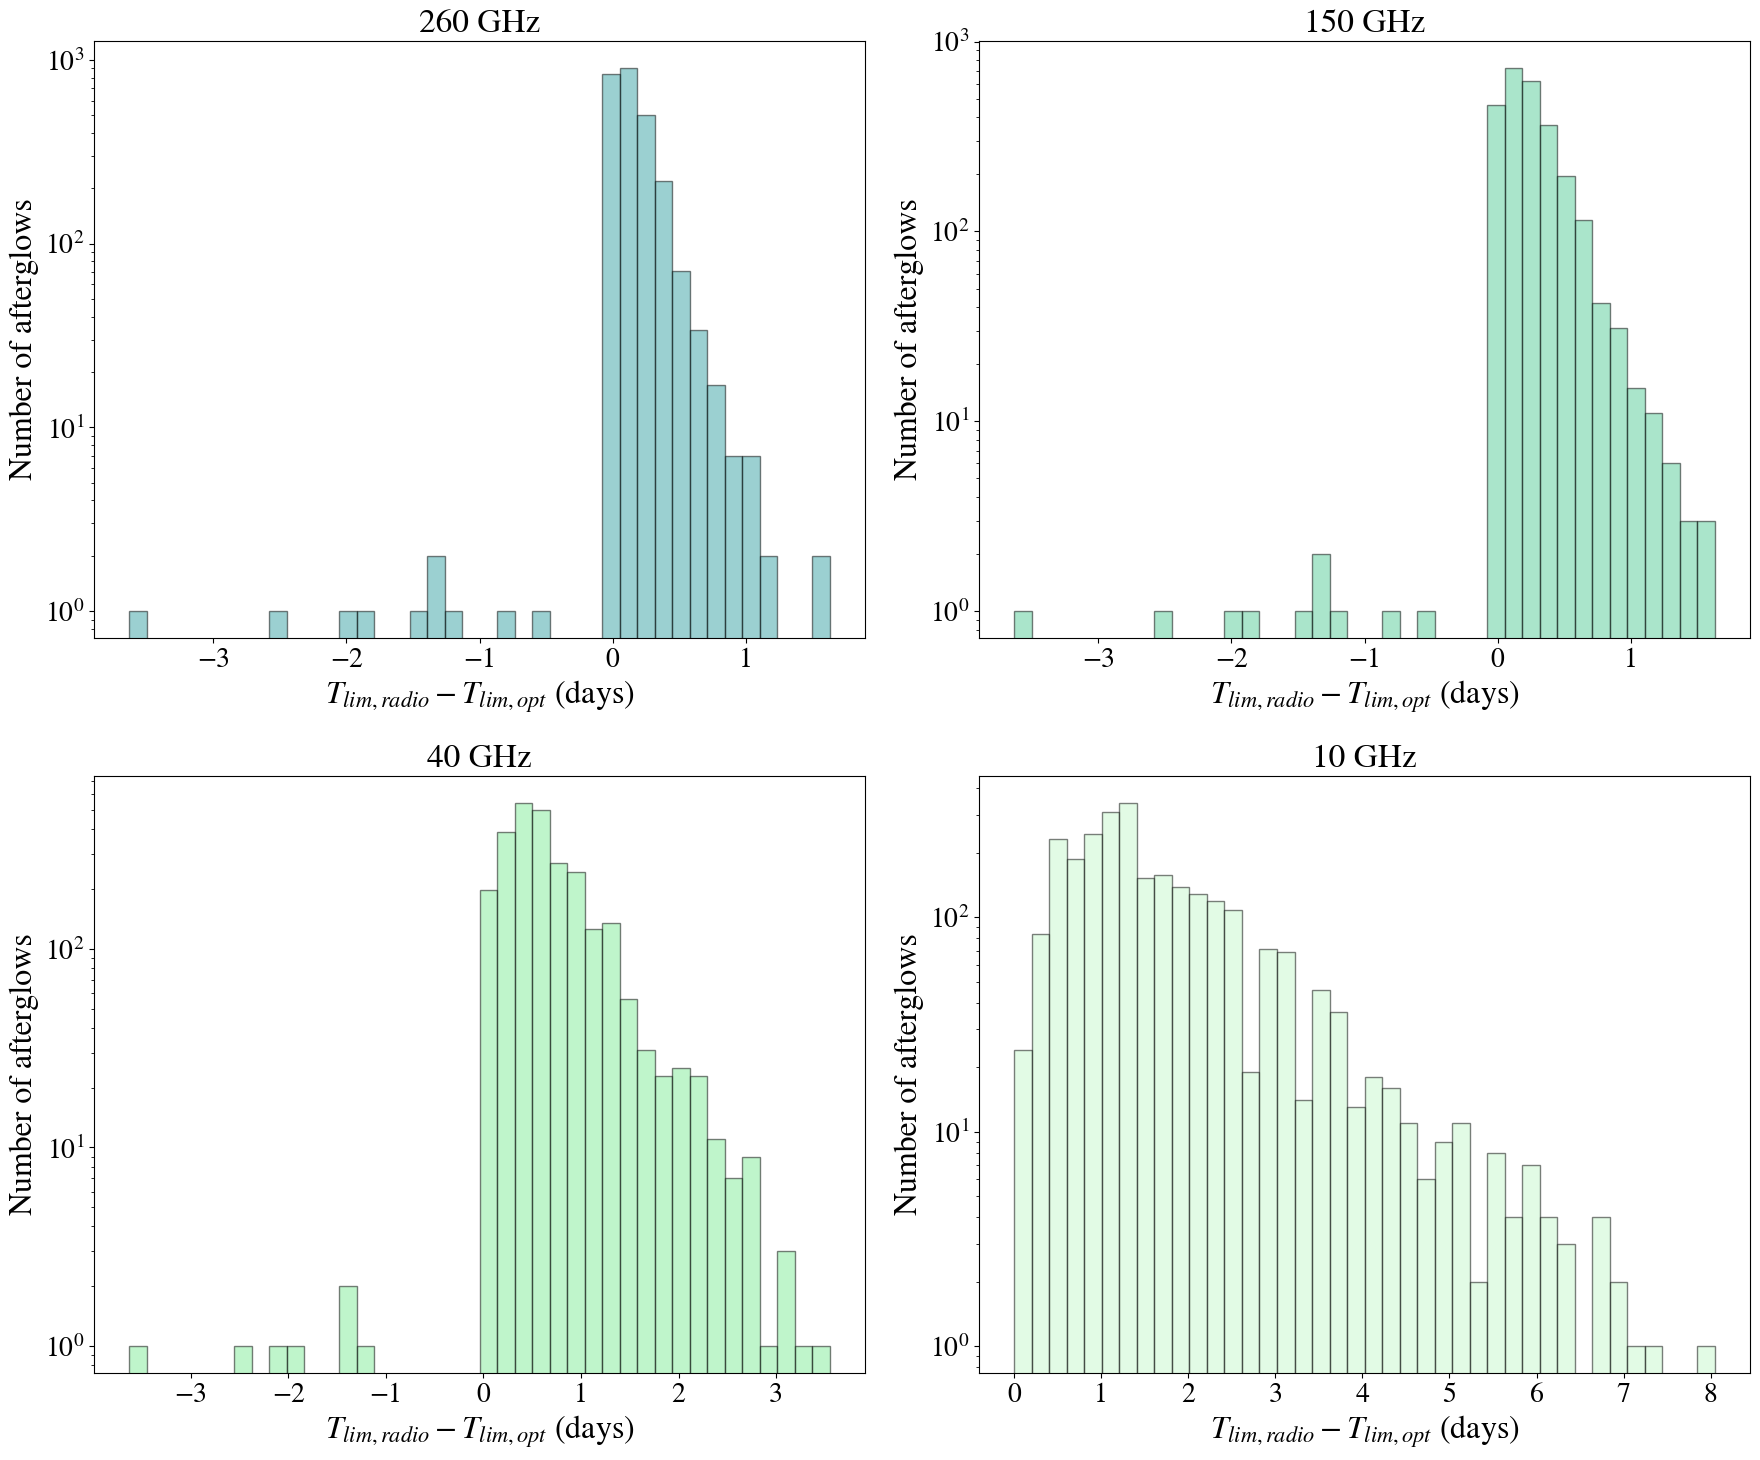

In [14]:
seuil_ALMA = [0.105, 0.165, 0.215] # ALMA detection thresholds at 40, 150, 260 GHz respectively

diff_pics_10_pop = []
diff_pics_40_pop = []
diff_pics_150_pop = []
diff_pics_260_pop = []

for i in range(len(Fnu_mab_pop)):
    diff_pics_10 = (t[np.where(Fnu_10_pop[i]==np.max(Fnu_10_pop[i]))[0][0]] - t[np.where(Fnu_mab_pop[i]==np.min(Fnu_mab_pop[i]))[0][0]])*grb.sec2day
    diff_pics_40 = (t[np.where(Fnu_40_pop[i]==np.max(Fnu_40_pop[i]))[0][0]] - t[np.where(Fnu_mab_pop[i]==np.min(Fnu_mab_pop[i]))[0][0]])*grb.sec2day
    diff_pics_150 = (t[np.where(Fnu_150_pop[i]==np.max(Fnu_150_pop[i]))[0][0]] - t[np.where(Fnu_mab_pop[i]==np.min(Fnu_mab_pop[i]))[0][0]])*grb.sec2day
    diff_pics_260 = (t[np.where(Fnu_260_pop[i]==np.max(Fnu_260_pop[i]))[0][0]] - t[np.where(Fnu_mab_pop[i]==np.min(Fnu_mab_pop[i]))[0][0]])*grb.sec2day
    diff_pics_10_pop.append(diff_pics_10)
    diff_pics_40_pop.append(diff_pics_40)
    diff_pics_150_pop.append(diff_pics_150)
    diff_pics_260_pop.append(diff_pics_260)

params = [diff_pics_260_pop, diff_pics_150_pop, diff_pics_40_pop, diff_pics_10_pop,]
titles = ['260 GHz','150 GHz','40 GHz','10 GHz']
colors = ['#38a3a5', '#57cc99','#80ed99', '#c7f9cc']

plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(18,15))

for i in range(len(params)):
    ax = plt.subplot(2,2,i+1)
    ax.hist(params[i],bins=40, log=True, color=colors[i], edgecolor='k', alpha=0.5)
    ax.set_xlabel('$T_{lim,radio} - T_{lim,opt}$ (days)', fontsize=23)
    ax.set_ylabel("Number of afterglows", fontsize=23)
    ax.set_title(titles[i])

plt.tight_layout()

#plt.savefig('../figures/orphan_obs_duration_after_opt_peak.pdf', format="pdf", bbox_inches="tight", transparent=True)

# Summary

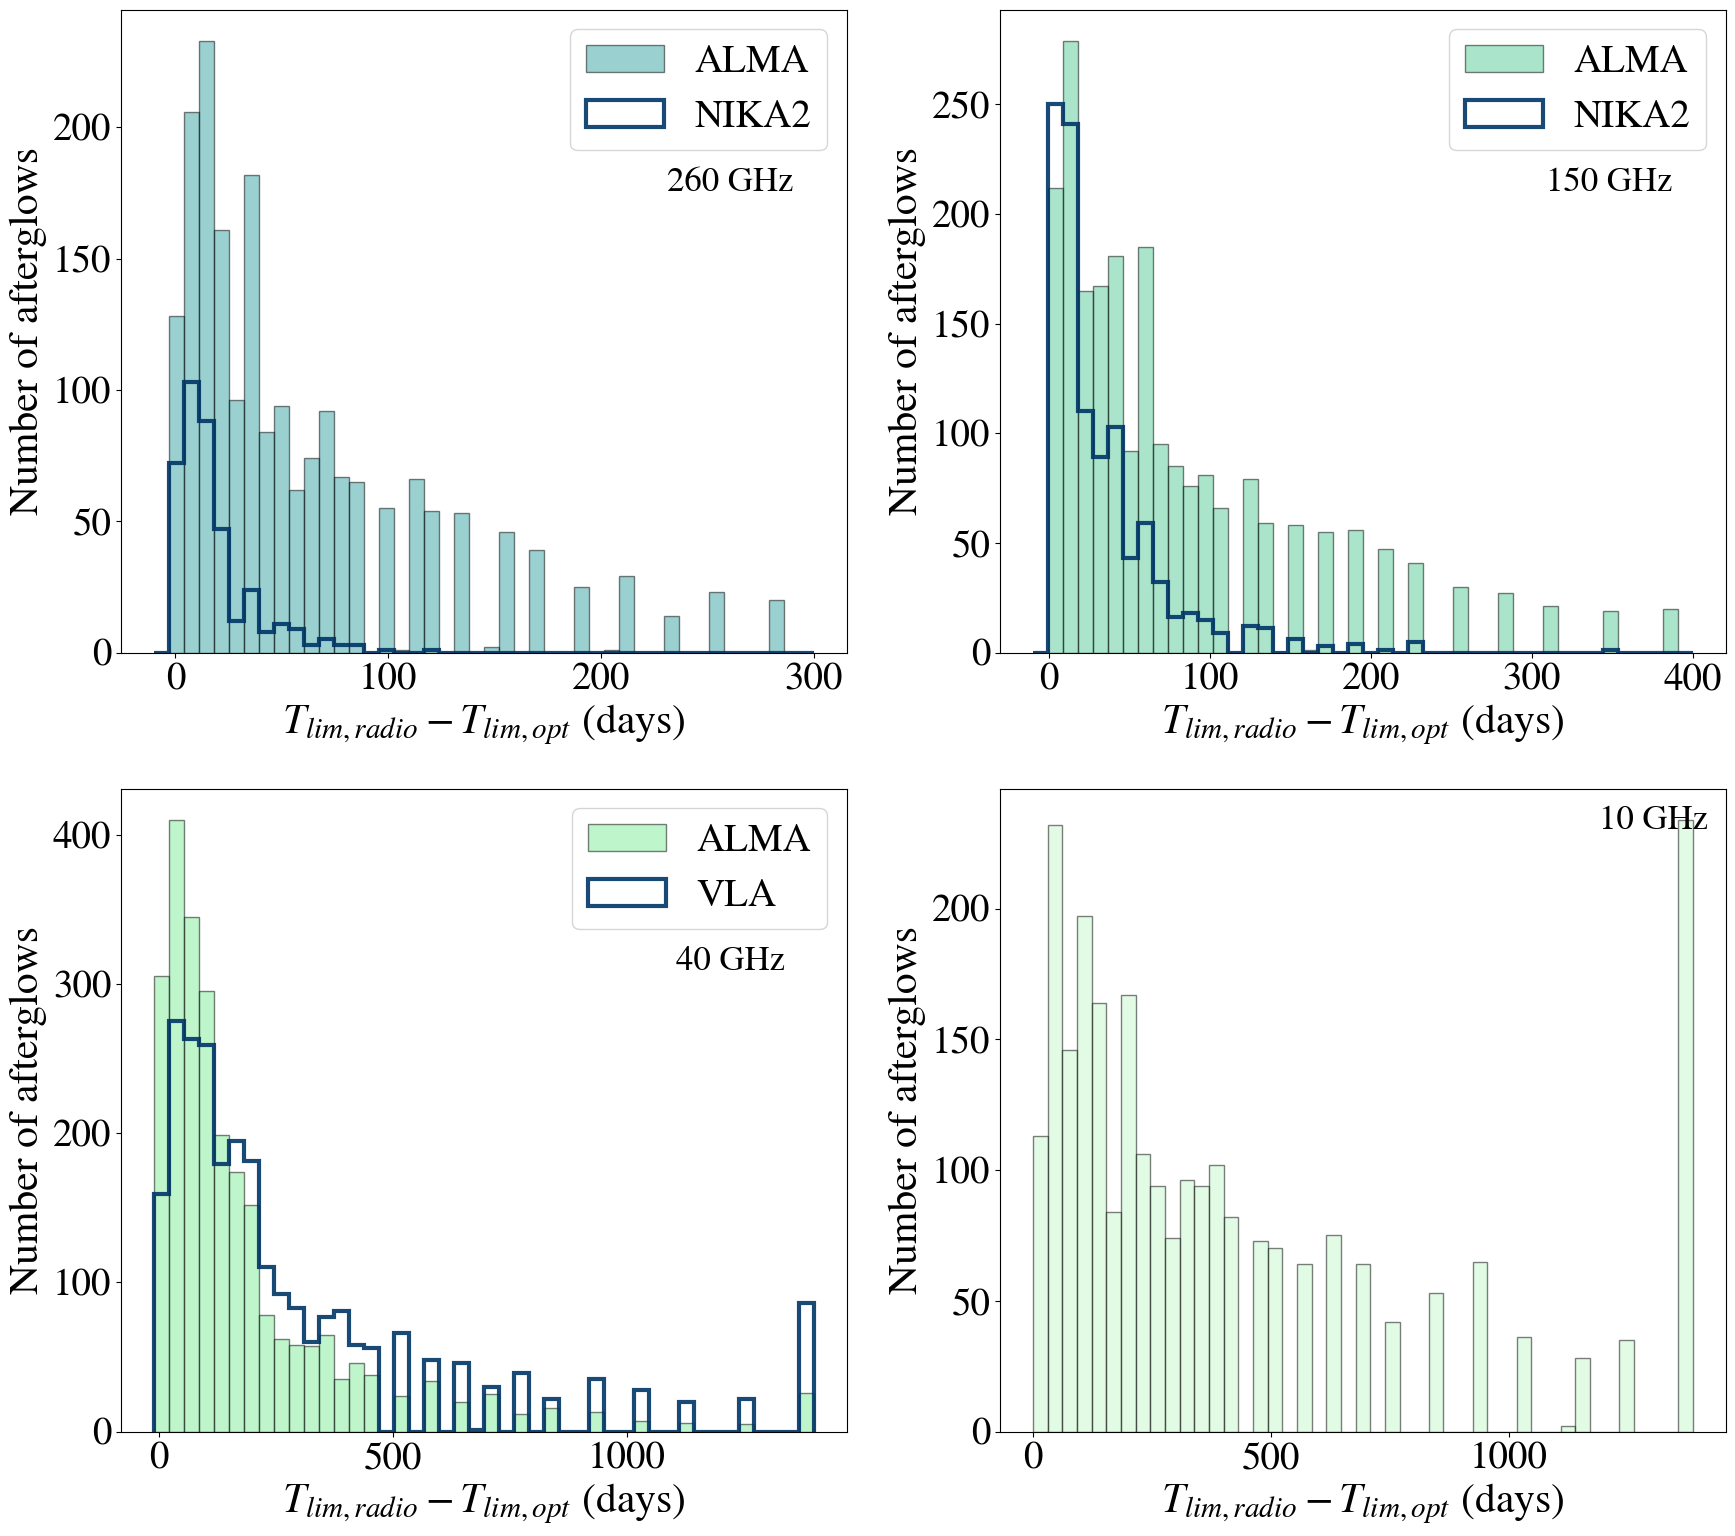

In [20]:
seuil_VLA = [0.0425,0.174]   # threshold at 10, 40 GHz for VLA
seuil_ALMA = [0.105, 0.165, 0.215]   # threshold at 40, 150, 260 GHz for ALMA
seuil_NIKA2 = [2, 7.5]   # threshold at 150, 260 GHz for NIKA2

diff_lim_10_pop = np.array([])
diff_lim_40_pop_VLA = np.array([])
diff_lim_40_pop_ALMA = np.array([])
diff_lim_150_pop_ALMA = np.array([])
diff_lim_150_pop_NIKA2 = np.array([])
diff_lim_260_pop_ALMA = np.array([])
diff_lim_260_pop_NIKA2 = np.array([])

t = np.geomspace(0.1*grb.day2sec, 1400*grb.day2sec, 100)

for i in range(len(Fnu_mab_pop)):
            
    if (len(t[np.where(Fnu_mab_pop[i]<24.5)[0]]*grb.sec2day) >= 15.):
        
        t_opt_15_days = t[np.where(Fnu_mab_pop[i]<24.5)[0]][0]*grb.sec2day + 15
        
        diff_lim_10 = t[np.where(Fnu_10_pop[i]>seuil_VLA[0])[0]]*grb.sec2day - t_opt_15_days
        diff_lim_40_VLA = t[np.where(Fnu_40_pop[i]>seuil_VLA[0])[0]]*grb.sec2day - t_opt_15_days
        diff_lim_40_ALMA = t[np.where(Fnu_40_pop[i]>seuil_ALMA[0])[0]]*grb.sec2day - t_opt_15_days
        diff_lim_150_ALMA = t[np.where(Fnu_150_pop[i]>seuil_ALMA[1])[0]]*grb.sec2day - t_opt_15_days
        diff_lim_150_NIKA2 = t[np.where(Fnu_150_pop[i]>seuil_NIKA2[0])[0]]*grb.sec2day - t_opt_15_days
        diff_lim_260_ALMA = t[np.where(Fnu_260_pop[i]>seuil_ALMA[2])[0]]*grb.sec2day - t_opt_15_days
        diff_lim_260_NIKA2 = t[np.where(Fnu_260_pop[i]>seuil_NIKA2[1])[0]]*grb.sec2day - t_opt_15_days
        
        if diff_lim_10.size>0:
            diff_lim_10_pop = np.append(diff_lim_10_pop,diff_lim_10[-1])
        if diff_lim_40_VLA.size>0:
            diff_lim_40_pop_VLA = np.append(diff_lim_40_pop_VLA, diff_lim_40_VLA[-1])
        if diff_lim_40_ALMA.size>0:
            diff_lim_40_pop_ALMA = np.append(diff_lim_40_pop_ALMA, diff_lim_40_ALMA[-1])
        if diff_lim_150_NIKA2.size>0:
            diff_lim_150_pop_NIKA2 = np.append(diff_lim_150_pop_NIKA2, diff_lim_150_NIKA2[-1])
        if diff_lim_150_ALMA.size>0:
            diff_lim_150_pop_ALMA = np.append(diff_lim_150_pop_ALMA, diff_lim_150_ALMA[-1])
        if diff_lim_260_ALMA.size>0:
            diff_lim_260_pop_ALMA = np.append(diff_lim_260_pop_ALMA, diff_lim_260_ALMA[-1])
        if diff_lim_260_NIKA2.size>0:
            diff_lim_260_pop_NIKA2 = np.append(diff_lim_260_pop_NIKA2, diff_lim_260_NIKA2[-1])


titles = ['260 GHz','150 GHz','40 GHz','10 GHz']
colors = ['#38a3a5', '#57cc99','#80ed99', '#c7f9cc']

plt.rcParams.update({'font.size': 28})
plt.figure(figsize=(18,16))

for i in range(4):
    ax = plt.subplot(2,2,i+1)
    if i==0:
        bin_edges = np.linspace(-10, 300, 45)
        ax.hist(diff_lim_260_pop_ALMA[diff_lim_260_pop_ALMA>0], bins=bin_edges, color=colors[i], edgecolor='k', alpha=0.5, label='ALMA')
        ax.hist(diff_lim_260_pop_NIKA2[diff_lim_260_pop_NIKA2>0], histtype='step', bins=bin_edges, color='#003566', linewidth=3, alpha=0.9, label='NIKA2')
        ax.legend()
        ax.text(0.84, 0.73, titles[i], fontsize=25, horizontalalignment='center', verticalalignment='center', transform = ax.transAxes)
        
    if i==1:
        bin_edges = np.linspace(-10, 400, 45)
        ax.hist(diff_lim_150_pop_ALMA[diff_lim_150_pop_ALMA>0], bins=bin_edges, color=colors[i], edgecolor='k', alpha=0.5, label='ALMA')
        ax.hist(diff_lim_150_pop_NIKA2[diff_lim_150_pop_NIKA2>0], histtype='step', bins=bin_edges, color='#003566', linewidth=3, alpha=0.9, label='NIKA2')
        ax.text(0.84, 0.73, titles[i], fontsize=25, horizontalalignment='center', verticalalignment='center', transform = ax.transAxes)
        ax.legend()
    
    if i==2:
        bin_edges = np.linspace(-10, 1400, 45)
        ax.hist(diff_lim_40_pop_ALMA[diff_lim_40_pop_ALMA>0], bins=bin_edges, color=colors[i], edgecolor='k', alpha=0.5, label='ALMA')
        ax.hist(diff_lim_40_pop_VLA[diff_lim_40_pop_VLA>0], histtype='step', bins=bin_edges, color='#003566', linewidth=3, alpha=0.9, label='VLA')
        ax.text(0.84, 0.73, titles[i], fontsize=25, horizontalalignment='center', verticalalignment='center', transform = ax.transAxes)
        ax.legend()
    
    if i==3:
        ax.hist(diff_lim_10_pop[diff_lim_10_pop>0], bins=45, color=colors[i], edgecolor='k', alpha=0.5)
        ax.text(0.9, 0.95, titles[i], fontsize=25, horizontalalignment='center', verticalalignment='center', transform = ax.transAxes)
        
    ax.set_xlabel('$T_{lim,radio} - T_{lim,opt}$ (days)', fontsize=30)
    ax.set_ylabel("Number of afterglows", fontsize=30)
    
plt.tight_layout()

#plt.savefig('../figures/orphan_obs_duration_after_opt_lim.pdf', format="pdf", bbox_inches="tight", transparent=True)